## Generation Evaluation Analysis Notebook

### Import Required Libraries

In [43]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

### Set up plotting style

In [44]:
sns.set(style="whitegrid")

## Load and Parse Results Data

### Load the results data

In [45]:
# Notebook is in notebooks/ so go up one level to project root
BASE_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
INPUT_DIR = BASE_DIR / "data/eval/input"
OUTPUT_DIR = BASE_DIR / "data/eval/output"

files = {
    "direct": OUTPUT_DIR / "generator_results_direct.json",
    "finetuned": OUTPUT_DIR / "generator_results_finetuned.json",
    "rag": OUTPUT_DIR / "generator_results_rag.json",
    "decomposed_rag": OUTPUT_DIR / "generator_results_decomposed_rag.json"
}

results = {}
for method, filepath in files.items():
    with open(filepath, "r") as f:
        results[method] = json.load(f)

Convert results to DataFrame

In [46]:
def json_to_df(data):
    records = []
    for key, entry in data.items():
        if key in ["query_count", "generation_time", "evaluation_time", "total_time"]:
            continue
        records.append({
            "id": int(key),
            "exact_match_accuracy": entry.get("exact_match_accuracy", 0),
            "functional_accuracy": entry.get("functional_accuracy", 0),
            "field_precision": entry.get("field_precision", 0),
            "field_recall": entry.get("field_recall", 0),
            "compilation_ratio": entry.get("compilation_ratio", 0)
        })
    return pd.DataFrame(records).set_index("id")

dfs = {method: json_to_df(res) for method, res in results.items()}

Compute summary statistics per method

In [47]:
rows = []

for method, df in dfs.items():
    # mean of metrics
    row = df.mean().to_dict()

    # add compilation_rate
    one_count = (df['compilation_ratio'] == 1.0).sum()
    row["compilation_rate"] = one_count / len(df)

    # add latency (time per dataset)
    time_taken = results[method].get("generation_time", 0)
    row["latency"] = time_taken / len(df) if len(df) > 0 else 0

    # calculate field_f1_score from precision and recall
    precision = row.get("field_precision", 0)
    recall = row.get("field_recall", 0)
    if precision + recall > 0:
        row["field_f1_score"] = 2 * (precision * recall) / (precision + recall)
    else:
        row["field_f1_score"] = 0

    row["method"] = method
    rows.append(row)

# Build summary DataFrame
summary = pd.DataFrame(rows).set_index("method")

In [48]:
summary

,exact_match_accuracy,functional_accuracy,field_precision,field_recall,compilation_ratio,compilation_rate,latency,field_f1_score
method,,,,,,,,
direct,0.399944,0.326706,0.223453,0.326706,0.679632,0.48,1.951513,0.265390
finetuned,0.401996,0.145754,0.126992,0.141825,0.277552,0.25,2.255249,0.133999
rag,0.459237,0.365792,0.267291,0.316928,0.718698,0.52,2.798932,0.290001
decomposed_rag,0.489879,0.461356,0.414900,0.424543,0.877666,0.85,20.615651,0.419666


Visualize metrics side by side

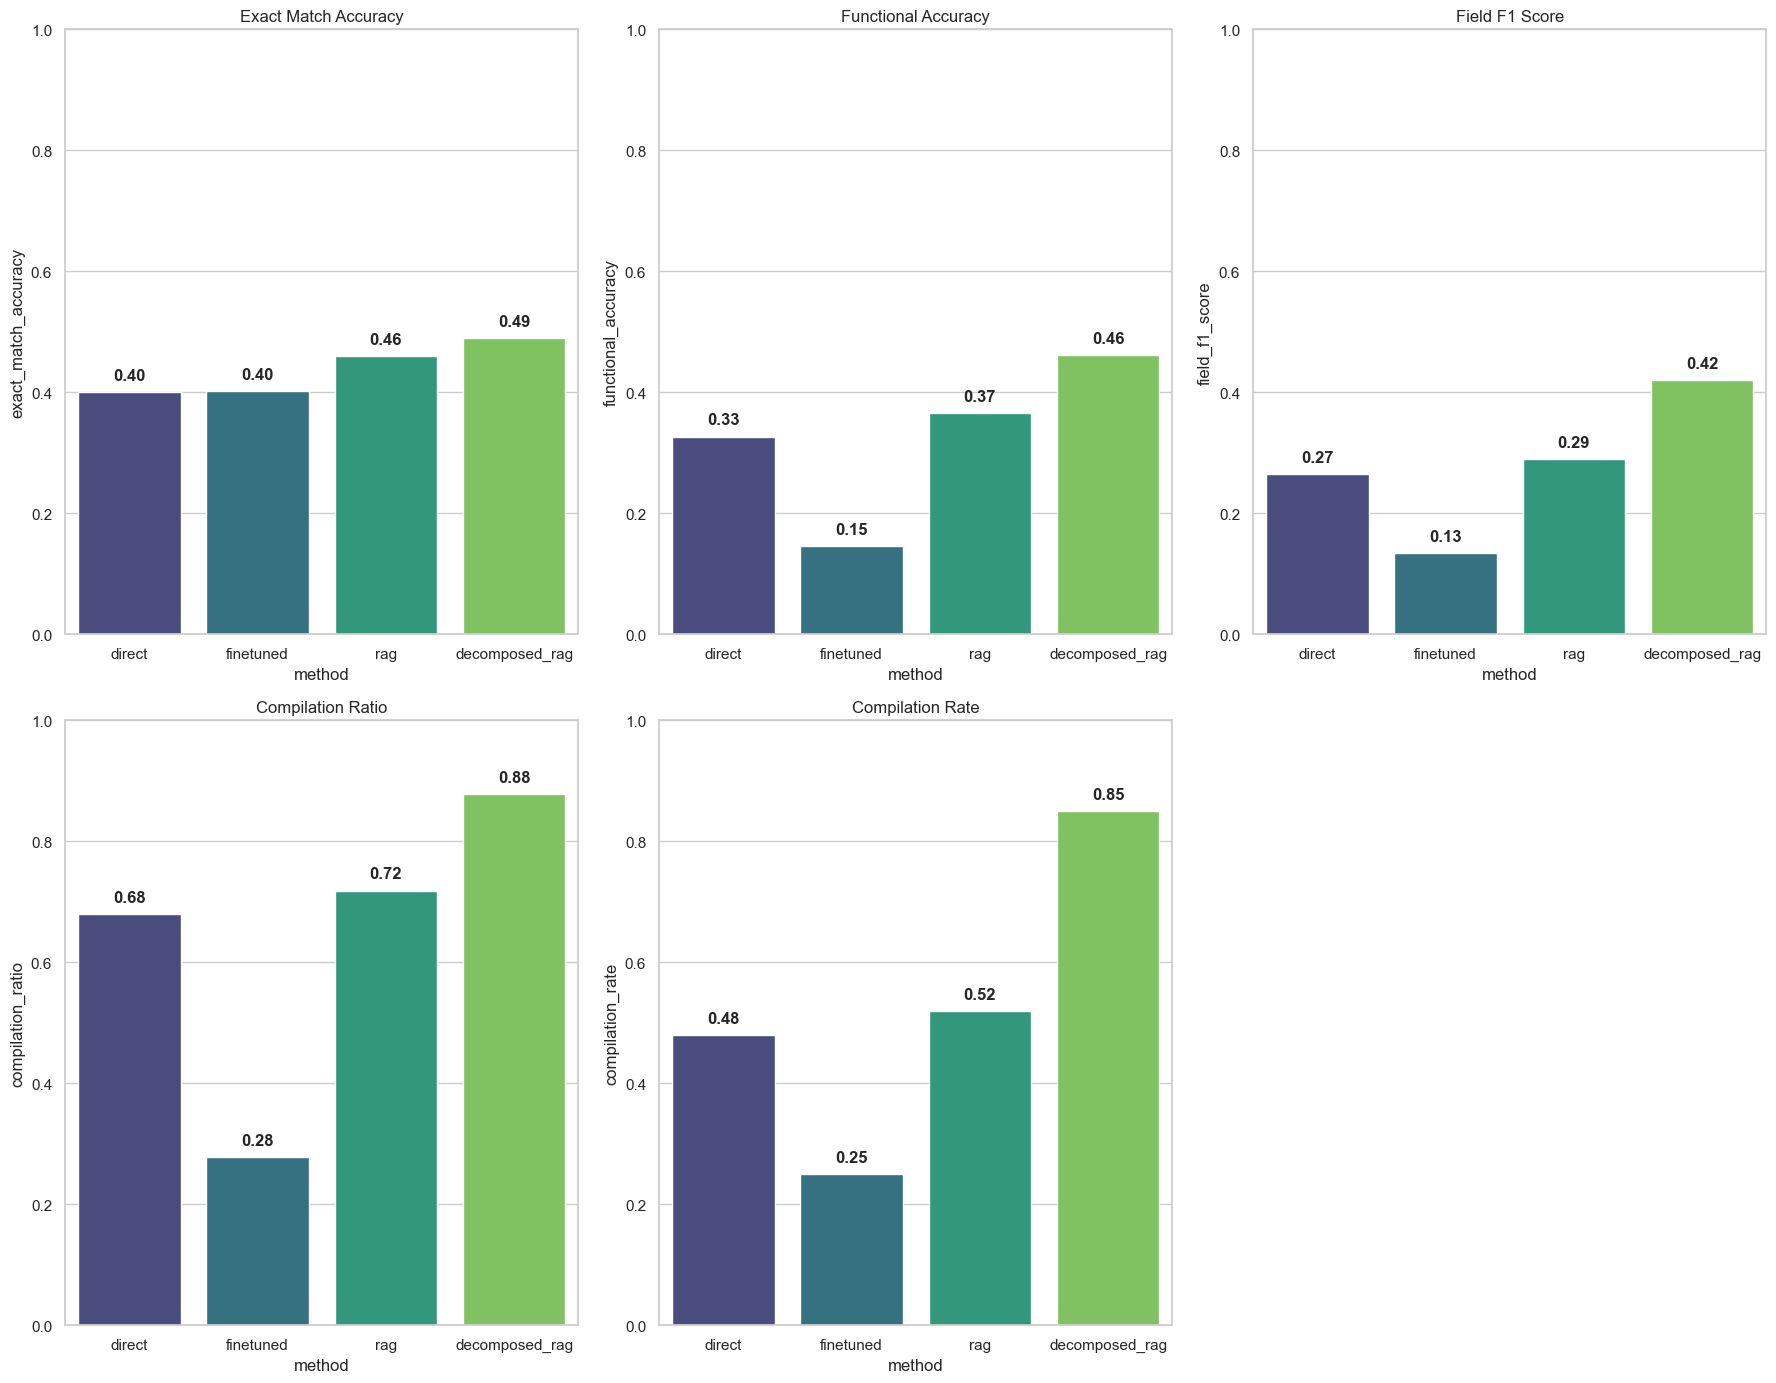

In [49]:
metrics = ["exact_match_accuracy", "functional_accuracy", "field_f1_score", "compilation_ratio", "compilation_rate"]

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 14))
axes = axes.flatten()

plotted = 0
for i, metric in enumerate(metrics):
    if metric not in summary.columns:
        continue
    sns.barplot(x=summary.index, y=summary[metric], ax=axes[plotted], palette="viridis", hue=summary.index)
    axes[plotted].set_title(metric.replace('_', ' ').title())
    
    # Set y-axis limit based on metric type
    if metric == "latency":
        axes[plotted].set_ylim(0, summary[metric].max() * 1.2)
        for j, v in enumerate(summary[metric]):
            axes[plotted].text(j, v + summary[metric].max() * 0.02, f"{v:.3f}s", ha='center', fontweight='bold')
    else:
        axes[plotted].set_ylim(0, 1)
        for j, v in enumerate(summary[metric]):
            axes[plotted].text(j, v + 0.02, f"{v:.2f}", ha='center', fontweight='bold')
    plotted += 1

# Remove any unused subplots
for k in range(plotted, len(axes)):
    fig.delaxes(axes[k])
plt.tight_layout()
plt.show()

Pairwise comparison heatmap

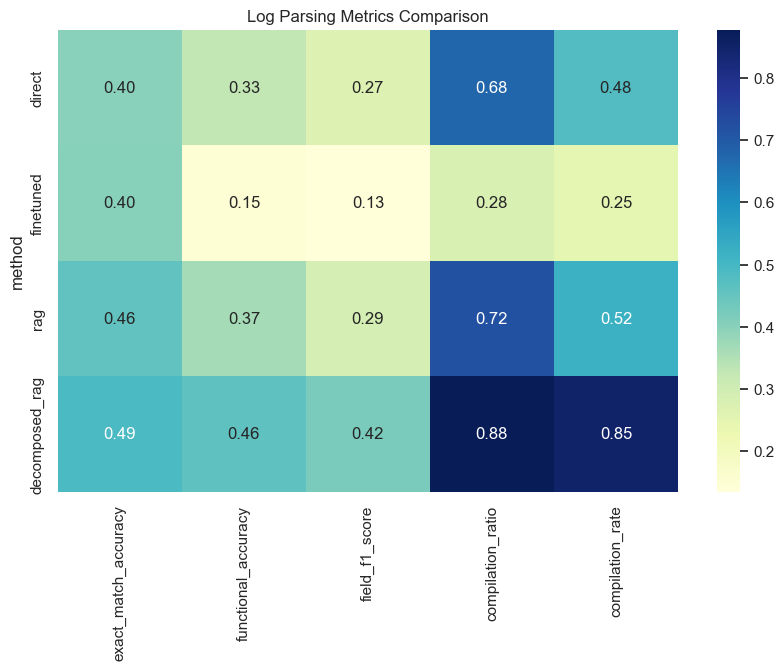

In [50]:
metrics_present = [m for m in metrics if m in summary.columns]
plt.figure(figsize=(10, 6))
sns.heatmap(summary[metrics_present], annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Log Parsing Metrics Comparison")
plt.show()